<a href="https://colab.research.google.com/github/AmrTamer217/DeepLearningARLtask/blob/main/Deep_Learning_ARL_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [560]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np

# First: Structuring the Neural Network

In [561]:
class Model(nn.Module):
  def __init__(self, in_features = 2, h1 = 8, h2 = 8, h3 = 8, out_features = 2):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.fc3 = nn.Linear(h2, h3)
    self.out = nn.Linear(h2, out_features)
  def forward(self, x):
    x = F.tanh(self.fc1(x))
    x = F.tanh(self.fc2(x))
    x = F.tanh(self.fc3(x))
    x = self.out(x)
    return x

In [562]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

#Second: Data Reading and Wrangling

In [563]:
df1 = pd.read_csv("spiral_data_train.csv")
df2 = pd.read_csv("spiral_labels_train.csv")

In [564]:
df1.head()

,X1,X2
0,-7.969139,-7.484732
1,5.800295,-12.143441
2,-6.705503,4.717379
3,0.947560,-12.680193
4,-5.792706,5.405557


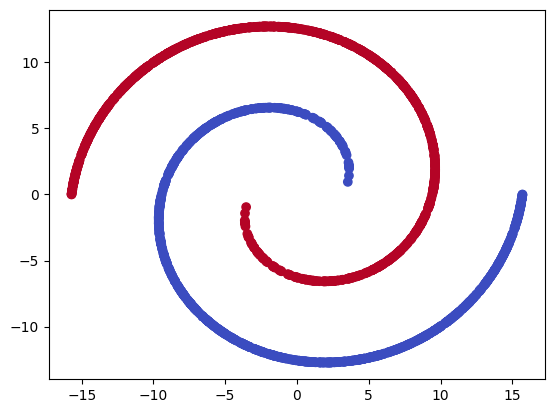

In [565]:
plt.scatter(df1['X1'], df1['X2'], c=df2['Label'], cmap='coolwarm')

Since the points form a spiral, converting them to polar coordinates makes it easier for the model to learn the pattern. In polar form, the spiral’s structure becomes simpler — instead of the x–y values wrapping around in complex curves, the relationship between the radius 𝑟 and the angle
𝜃 becomes more direct and continuous. This helps the model capture the underlying relationship between points and their corresponding spiral more effectively.

In [566]:
df1['theta'] = np.arctan2(df1['X2'], df1['X1'])
df1['r'] = np.sqrt(df1['X1']**2 + df1['X2']**2)

In [567]:
X = df1.drop(['X1', 'X2'], axis = 1).values
y = df2.values

Splitting the data into training data and testing data

In [568]:
from sklearn.model_selection import train_test_split

In [569]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4)

In [570]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [571]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

#Third: Training the Neural Network

In [572]:
model = Model()

In [573]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [574]:
epochs = 100
losses = []
for i in range(epochs):
  y_pred = model.forward(X_train)
  loss = criterion(y_pred, y_train.squeeze())
  losses.append(loss.detach().numpy())
  if i % 20 == 0:
    print(f"Epoch: {i} Loss: {loss}")
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 Loss: 0.7029375433921814
Epoch: 20 Loss: 0.5635509490966797
Epoch: 40 Loss: 0.24827682971954346
Epoch: 60 Loss: 0.023779457435011864
Epoch: 80 Loss: 0.0020210598595440388


In [575]:
print(losses[-1])

0.00093830714


Text(0.5, 0, 'Epochs')

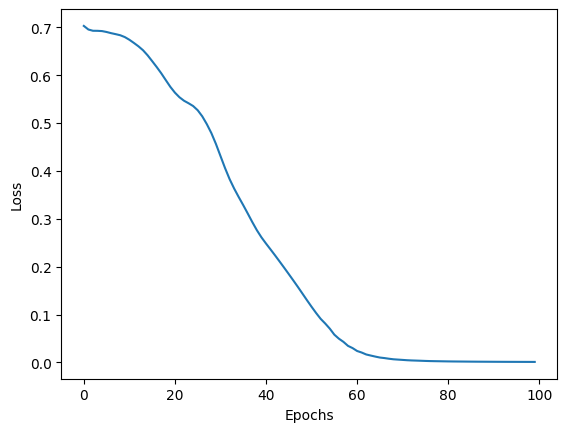

In [576]:
plt.plot(range(epochs), losses)
plt.ylabel("Loss")
plt.xlabel("Epochs")

#Fourth: Evaluating the Model (using the remaining data)

In [577]:
with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test.squeeze())

In [578]:
loss

tensor(0.0008)

In [579]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)
    if y_val.argmax().item() == y_test[i]:
      correct += 1
print(f"Accuracy: {correct/len(y_test)}")

Accuracy: 1.0


#Fifth: Labeling the Test Data

In [580]:
df_test = pd.read_csv("spiral_data_test.csv")

In [581]:
df_test['theta'] = np.arctan2(df_test['X2'], df_test['X1'])
df_test['r'] = np.sqrt(df_test['X1']**2 + df_test['X2']**2)
X = torch.tensor(df_test.drop(['X1', 'X2'], axis = 1).values, dtype=torch.float32)

In [582]:
with torch.no_grad():
    outputs = model(X)
    preds = torch.argmax(outputs, dim=1)

In [583]:
df_test['Label'] = preds.numpy()

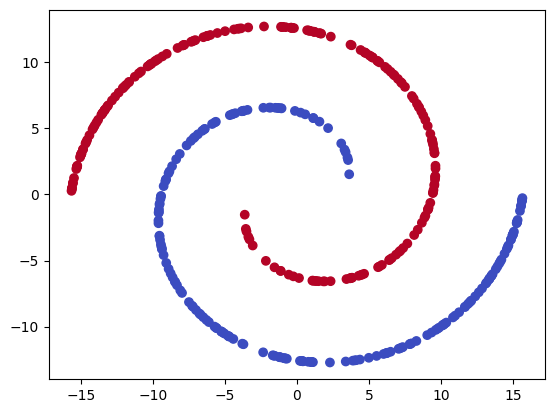

In [584]:
plt.scatter(df_test['X1'], df_test['X2'], c=df_test['Label'], cmap='coolwarm')

In [585]:
pd.DataFrame(df_test.drop(['theta', 'r'], axis = 1)).to_csv('spiral_test_results.csv', index=False)